# Thống kê mô tả bệnh tiểu đường

## 1. Định nghĩa
+ **Mô tả**: Bộ dữ liệu Diabetes (Bệnh tiểu đường) chứa thông tin y tế của nhiều bệnh nhân nữ người Mỹ gốc da đỏ, được sử dụng để dự đoán khả năng mắc bệnh tiểu đường dựa trên các chỉ số lâm sàng. Mỗi dòng dữ liệu tương ứng với một bệnh nhân và các giá trị đo lường sức khỏe của họ.
+ **Dữ liệu vào**:
  + Pregnancies: số lần mang thai

  + Glucose: nồng độ glucose huyết tương sau 2 giờ (mg/dL)

  + BloodPressure: huyết áp tâm trương (mm Hg)

  + SkinThickness: độ dày lớp da gấp dưới cánh tay (mm)

  + Insulin: nồng độ insulin huyết tương (mu U/ml)

  + BMI: chỉ số khối cơ thể (Body Mass Index)

  + DiabetesPedigreeFunction: chỉ số di truyền tiểu đường

  + Age: tuổi của bệnh nhân (năm)

  + Outcome: kết quả chẩn đoán (0 = không mắc bệnh, 1 = mắc bệnh)


## 2. Import các thư viện cần thiết

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns  #for data visualization operations
from scipy import stats

## 3. Load dữ liệu

In [4]:
data = pd.read_csv("/content/sample_data/diabetes.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. Loại bỏ dữ liệu trùng lặp

In [7]:
# Kiểm tra số lượng dòng trùng lặp
data.duplicated().sum()

# Loại bỏ các dòng trùng lặp
data_duplicate = data.drop_duplicates()

# Kiểm tra kích thước sau khi loại bỏ trùng lặp
data_duplicate.shape

# Xóa một dòng cụ thể theo index
data.drop(labels=[1], axis=0)

# Xóa một cột cụ thể
data.drop(labels=['Insulin'], axis=1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,33.6,0.627,50,1
1,1,85,66,29,26.6,0.351,31,0
2,8,183,64,0,23.3,0.672,32,1
3,1,89,66,23,28.1,0.167,21,0
4,0,137,40,35,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,48,32.9,0.171,63,0
764,2,122,70,27,36.8,0.340,27,0
765,5,121,72,23,26.2,0.245,30,0
766,1,126,60,0,30.1,0.349,47,1


## 5. Thay thế và thay đổi định dạng dữ liệu

In [8]:
# Thay thế giá trị trong cột Outcome
data['Outcome_label'] = data['Outcome'].replace(
    [0, 1],
    ['No Diabetes', 'Diabetes'])

# Điền giá trị thiếu cho cột Glucose bằng 0
data['Glucose'] = data['Glucose'].fillna(0)

# Chuyển kiểu dữ liệu Glucose sang float
data['Glucose_changed'] = data['Glucose'].astype(float)

## 6. Xử lý dữ liệu thiếu

In [6]:
# Kiểm tra tổng số giá trị thiếu ở từng cột
print(data.isnull().sum())

# Điền giá trị thiếu
# Với dữ liệu số: điền bằng trung bình
# Với dữ liệu phân loại điền bằng giá trị phổ biến nhất
for col in data.columns:
    if data[col].dtype != 'object':
        data[col] = data[col].fillna(data[col].mean())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])

# Kiểm tra lại sau khi xử lý
print(data.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,alcohol_changed
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,14.900000


## 7. Tính các giá trị

In [11]:
# Tính giá trị trung bình (mean) của cột Glucose
data_mean = np.mean(data['Glucose'])
# Tính giá trị trung vị (Median) của cột Glucose
data_median = np.median(data['Glucose'])
# Tính giá trị mode (Giá trị xuất hiện nhiều nhất)
data_mode = stats.mode(data['Glucose'], keepdims=True)[0][0]
# Tính giá trị phương sai (Variance)
data_variance = np.var(data['Glucose'])
# Tính giá trị lệch chuẩn (Standard Deviation)
data_std = np.std(data['Glucose'])
# Tính giá trị nhỏ nhất (Minimum)
data_min = np.min(data['Glucose'])
# Tính giá trị lớn nhất (Maximum)
data_max = np.max(data['Glucose'])
# Tính khoảng giá trị (Range)
data_range = data_max - data_min
# Tính Percentile thứ 60 (giá trị tại vị trí 60%)
data_percentile_60 = np.percentile(data['Glucose'], 60)
# Tính phần tư thứ nhất (Q1)
data_quartile_1 = np.quantile(data['Glucose'], 0.25)
# Tính phần tư thứ ba (Q3)
data_quartile_3 = np.quantile(data['Glucose'], 0.75)
# Tính khoảng tứ phân vị (Interquartile Range - IQR)
data_IQR = stats.iqr(data['Glucose'])

In [12]:
print(f"Mean: {data_mean}")
print(f"Median: {data_median}")
print(f"Mode: {data_mode}")
print(f"Variance: {data_variance}")
print(f"Standard Deviation: {data_std}")
print(f"Range: {data_range}")
print(f"60th Percentile: {data_percentile_60}")
print(f"1st Quartile (Q1): {data_quartile_1}")
print(f"3rd Quartile (Q3): {data_quartile_3}")
print(f"IQR (Q3 - Q1): {data_IQR}")

Mean: 120.89453125
Median: 117.0
Mode: 99
Variance: 1020.9172617594401
Standard Deviation: 31.95179590820272
Range: 199
60th Percentile: 125.0
1st Quartile (Q1): 99.0
3rd Quartile (Q3): 140.25
IQR (Q3 - Q1): 41.25


## 6. Trực quan hóa dữ liệu

### 6.1. Biểu đồ phân bố tần suất - Histogram

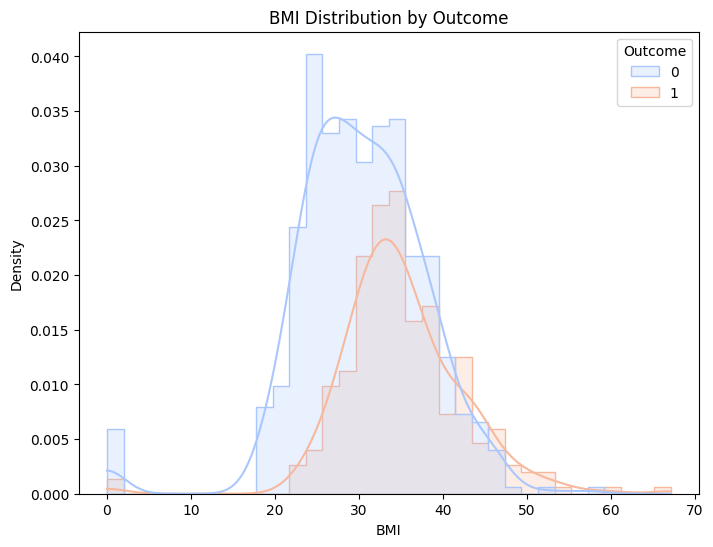

In [7]:
plt.figure(figsize=(8,6))
sns.histplot(data=data, x='BMI', hue='Outcome', kde=True, palette='coolwarm', element='step', stat='density')
plt.title('BMI Distribution by Outcome')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.show()

### 6.2. Biểu đồ hộp - Boxplot

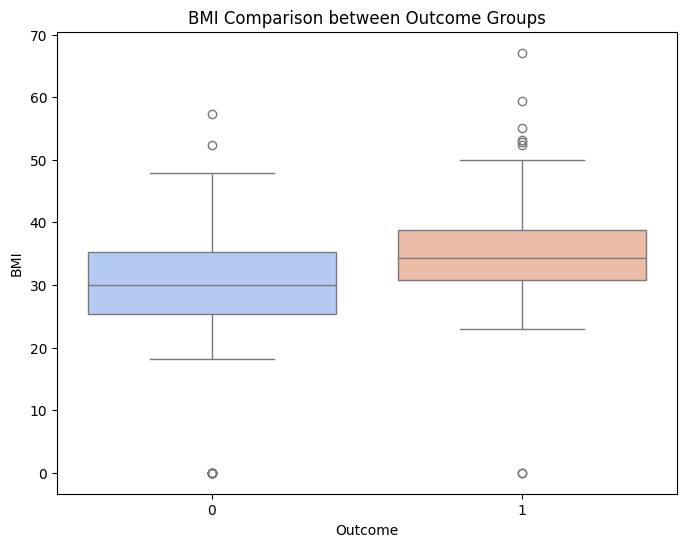

In [8]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Outcome', y='BMI', data=data, hue='Outcome', palette='coolwarm', legend=False)
plt.title('BMI Comparison between Outcome Groups')
plt.xlabel('Outcome')
plt.ylabel('BMI')
plt.show()

### 6.3. Biểu đồ KDE Plot


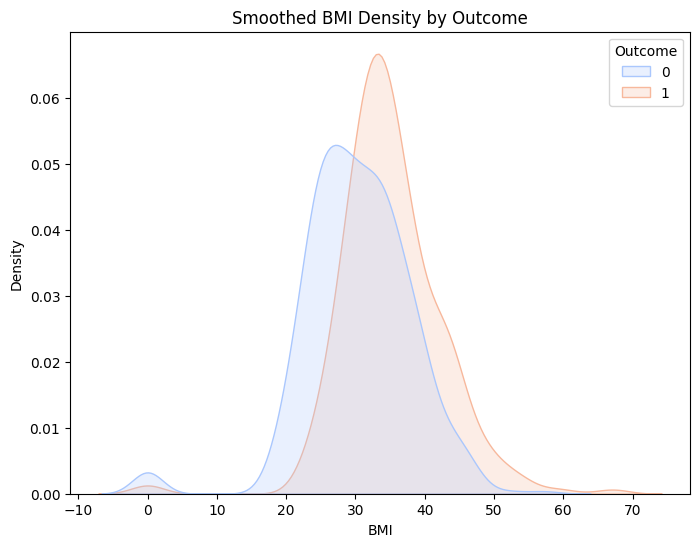

In [10]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=data, x='BMI', hue='Outcome', fill=True, common_norm=False, palette='coolwarm')
plt.title('Smoothed BMI Density by Outcome')
plt.xlabel('BMI')
plt.ylabel('Density')
plt.show()

### 6.4. Biểu đồ Violin

/tmp/ipython-input-4049388455.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='BMI', data=data, palette='muted')


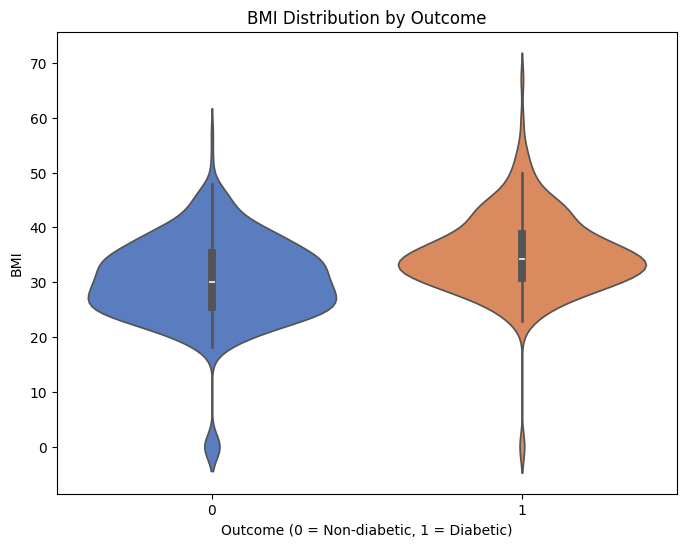

In [26]:
plt.figure(figsize=(8,6))
sns.violinplot(x='Outcome', y='BMI', data=data, palette='muted')
plt.title('BMI Distribution by Outcome')
plt.xlabel('Outcome (0 = Non-diabetic, 1 = Diabetic)')
plt.ylabel('BMI')
plt.show()

## 6.5. Biểu đồ Scatter Plot

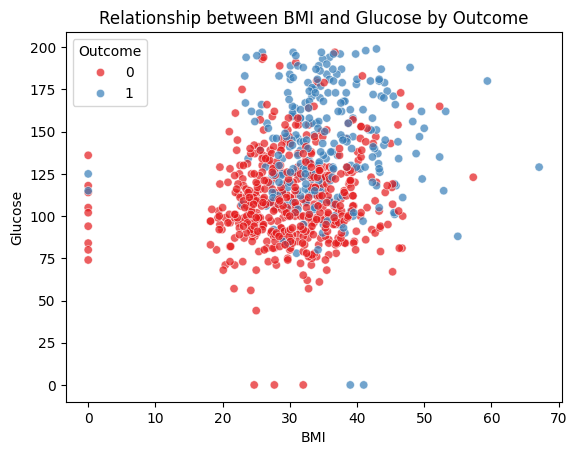

In [12]:
sns.scatterplot(data=data, x='BMI', y='Glucose', hue='Outcome', palette='Set1', alpha=0.7)
plt.title('Relationship between BMI and Glucose by Outcome')
plt.xlabel('BMI')
plt.ylabel('Glucose')
plt.show()

# Kết thúc